# Analyse simulated trajectories

In [1]:
from time import time
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = str(-1)

import h5py
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import config, jit
from jax.numpy.fft import fft, fftn, ifftn, irfft, irfftn, rfft, rfftn
from jax_sph.io_state import read_h5, write_h5, write_vtks_from_h5s
from matplotlib.colors import LogNorm
from PIL import Image

from l3es.init_fields import init_u_hit
from l3es.turbulence import mls_2nd_order, ur_to_u_mls_wrapper
from l3es.utils import energy_spectrum
from l3es.visualize import plot_e_k, plot_views

config.update("jax_enable_x64", True)

## 1. Start particle evolution from JAX-SPH relaxed trajectories

Relaxations based on jax-sph:
```bash
python main.py config=cases/tgv.yaml case.dim=2 case.mode=rlx solver.tvf=1.0 case.dx=0.03125 seed=42 case.r0_noise_factor=0.25 io.data_path=data_relaxed/ eos.p_bg_factor=0.02

python main.py config=cases/tgv.yaml case.dim=2 case.mode=rlx solver.tvf=1.0 case.dx=0.015625 seed=42 case.r0_noise_factor=0.25 io.data_path=data_relaxed/ eos.p_bg_factor=0.02

python main.py config=cases/tgv.yaml case.dim=3 case.mode=rlx solver.tvf=1.0 case.dx=0.19634954 seed=42 case.r0_noise_factor=0.25 io.data_path=data_relaxed/ eos.p_bg_factor=0.02
```

In [4]:
### ! WARNING ! ###
# Run only once, as this rescales the TGV data

state_0_paths = [
    # "../data_relaxed/tgv_2_0.03125_42.h5",  # 32x32
    "../data_relaxed/tgv_2_0.015625_42.h5",  # 64x64
    "../data_relaxed/tgv_3_0.19634954_42.h5",  # 32x32x32
]

# # remove all but coordinates from relaxed state
# # and rescale 2D TGV to 2pi box
# for path_i, rescale_factor in zip(state_0_paths, [2*np.pi, 1.0]):
#     state_0 = read_h5(path_i)
#     state_0 = {"r": state_0["r"]*rescale_factor}
#     write_h5(state_0, path_i)

(0.0, 6.283185307179586)

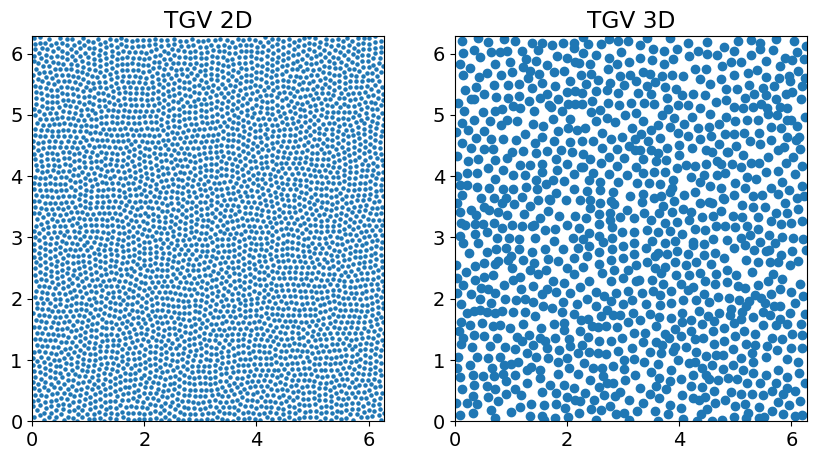

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

r = read_h5(state_0_paths[0])["r"]
axs[0].scatter(r[:, 0], r[:, 1], s=5)
axs[0].set_title("TGV 2D")
axs[0].set_xlim(0, 2*np.pi); axs[0].set_ylim(0, 2*np.pi)

r = read_h5(state_0_paths[1])["r"]
mask = r[:, 2] < 0.2
axs[1].scatter(r[:, 0][mask], r[:, 1][mask])
axs[1].set_title("TGV 3D")
axs[1].set_xlim(0, 2*np.pi); axs[1].set_ylim(0, 2*np.pi)

## TGV 2D

Generate GT with spectral method.
```bash
python main.py config=configs/kolmogorov.yaml
# t_tot = 41.083, t_sim = 0.278
```

Evolve particles.
```bash
python main.py config=configs/kolmogorov.yaml mode=integrate
# t_tot = 235.213, t_int = 218.198
```

With smaller time steps:
```bash
python main.py config=configs/kolmogorov.yaml sim.t_final=0.1 sim.dt=0.0001
# t_tot = 29.364, t_sim = 0.258
python main.py config=configs/kolmogorov.yaml mode=integrate sim.t_final=0.1 sim.dt=0.0001
# t_tot = 244.480, t_int = 225.295
```


TGV 2D:
```bash
python main.py config=configs/tgv2d.yaml gpu=7
# t_tot = 18.165, t_sim = 0.271
python main.py config=configs/tgv2d.yaml mode=integrate gpu=7
# t_tot = 235.213, t_int = 218.198

# this didn't really work well. More density oscillations.
python main.py config=configs/tgv2d.yaml int.dst_path=results_tgv2d_fine sim.dst_path=results_tgv2d_fine sim.dt=0.0002 gpu=7
#
python main.py config=configs/tgv2d.yaml mode=integrate int.dst_path=results_tgv2d_fine sim.dst_path=results_tgv2d_fine sim.dt=0.0002 gpu=7
#

```

### Relaxation during integration

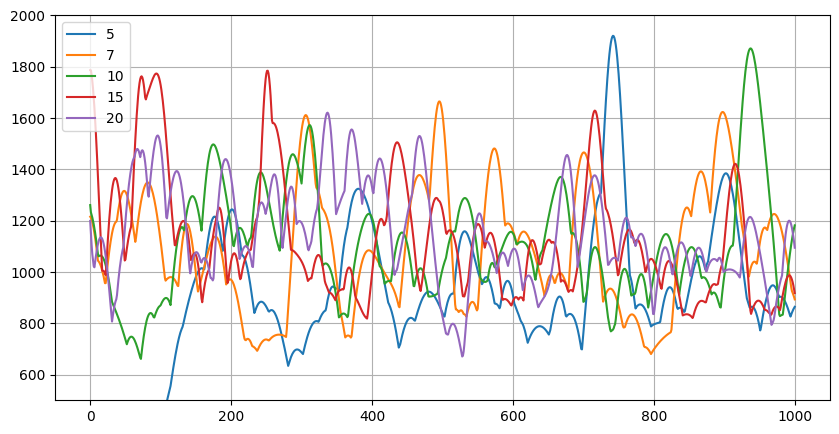

In [9]:
import pickle
with open("../results_tgv2d/accs.pkl", "rb") as f:
    accs = pickle.load(f)
    
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))
for k, v in accs.items():
    if k<22:
        plt.plot(v, label=k)
    
plt.ylim(500, 2000)
# plt.yscale("log")
plt.legend()
plt.grid()

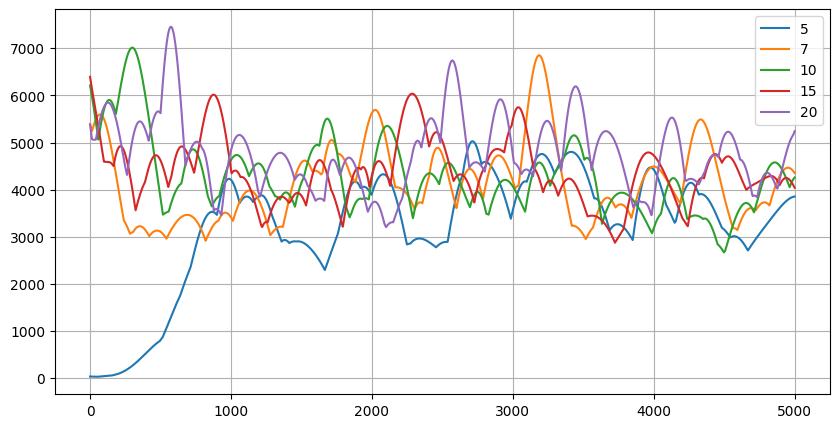

In [21]:
import pickle
with open("../results_tgv2d_fine/accs.pkl", "rb") as f:
    accs = pickle.load(f)

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))
for k, v in accs.items():
    if k<22:
        plt.plot(v, label=k)

# plt.ylim(500, 2000)
# plt.yscale("log")
plt.legend()
plt.grid()

## 2D Kolmogorov

Generate GT with spectral method.
```bash
python main.py config=configs/kolmogorov64.yaml
# t_tot = , t_sim = 
```

Evolve particles.
```bash
python main.py config=configs/kolmogorov.yaml mode=integrate
# t_tot = , t_int = 
```

<!-- 

With smaller time steps:
```bash
python main.py config=configs/kolmogorov.yaml sim.t_final=0.1 sim.dt=0.0001
# t_tot = 29.364, t_sim = 0.258
python main.py config=configs/kolmogorov.yaml mode=integrate sim.t_final=0.1 sim.dt=0.0001
# t_tot = 244.480, t_int = 225.295
```


TGV 2D:
```bash
python main.py config=configs/tgv2d.yaml gpu=7
# t_tot = 18.165, t_sim = 0.271
python main.py config=configs/tgv2d.yaml mode=integrate gpu=7
# t_tot = 235.213, t_int = 218.198

# this didn't really work well. More density oscillations.
python main.py config=configs/tgv2d.yaml int.dst_path=results_tgv2d_fine sim.dst_path=results_tgv2d_fine sim.dt=0.0002 gpu=7
#
python main.py config=configs/tgv2d.yaml mode=integrate int.dst_path=results_tgv2d_fine sim.dst_path=results_tgv2d_fine sim.dt=0.0002 gpu=7
#

``` -->

In [4]:
write_vtks_from_h5s("../results_kolm64_comb/com")
os.makedirs("../results_kolm64_comb/com_vtk", exist_ok=True)
os.system("mv ../results_kolm64_comb/com/*.vtk ../results_kolm64_comb/com_vtk")

0

In [3]:
with h5py.File("../dataset_kolm/train.h5", "r") as f:
    for k, v in f.items():
        for k2, v2 in v.items():
            print(k, k2, v2.shape)

00000 particle_type (4096,)
00000 position (201, 4096, 2)
00000 u (201, 4096, 2)
00001 particle_type (4096,)
00001 position (201, 4096, 2)
00001 u (201, 4096, 2)


(4096, 2) (4096, 2)


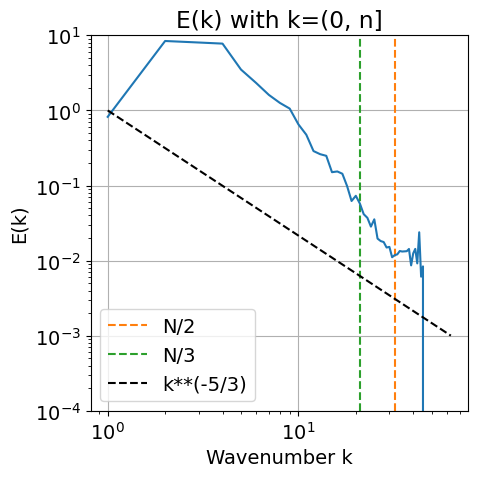

In [4]:
N = 64
L = 2 * np.pi
dim = 2

r = h5py.File("../dataset_kolm/train.h5")["00000/position"][200]
u_r = h5py.File("../dataset_kolm/train.h5")["00000/u"][200]
u_grid = ur_to_u_mls_wrapper(N, L, dim)(r, u_r)
print(u_r.shape, u_grid.shape)

u_grid = np.asarray((u_grid.T).reshape((dim, N, N)))
if dim == 2:
    u_grid = np.vstack([u_grid, np.zeros_like(u_grid[:1])])[:, :, :, None]
# spectrum = energy_spectrum(u_grid, dim=dim)

# plt.figure(figsize=(10, 5))
# plt.loglog(spectrum)
# plt.grid()

plot_e_k(u_grid, 0, dim=dim)